# **XGBoost Classifier**


=== 1 : XGBoost Classifier ===
Algorithm Selected: XGBoost (Extreme Gradient Boosting)

Rationale:
- Ensemble tree-based method → Excellent for tabular data
- Handles missing values and non-linear relationships well
- Built-in regularization (prevents overfitting)
- Fast training and high performance on classification tasks
- Provides feature importance natively

Dataset Shape: (27880, 13)
Target Distribution:
 Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Training set: (22304, 12)
Test set: (5576, 12)

Training Default XGBoost...
=== Default XGBoost Results ===
Training Time: 0.28 seconds
Accuracy : 0.8341
AUC Score: 0.9019
F1 Score : 0.8605

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80      2310
           1       0.85      0.87      0.86      3266

    accuracy                           0.83      5576
   macro avg       0.83      0.83      0.83      5576
weighted avg       0.83    

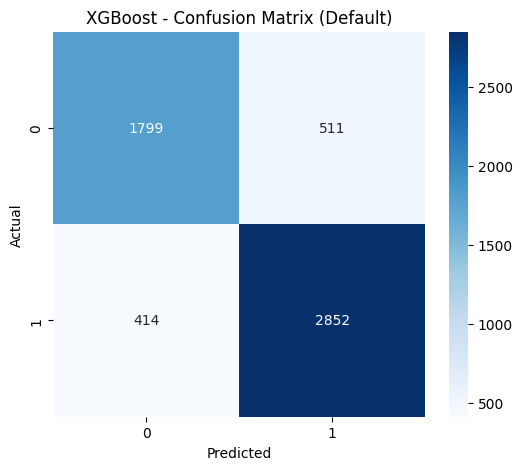


Performing 5-Fold Stratified Cross-Validation...
Cross-Validation Results (Mean ± Std):
Accuracy    : 0.8294 ± 0.0051
F1          : 0.8562 ± 0.0042
Roc_auc     : 0.9001 ± 0.0040
Precision   : 0.8452 ± 0.0045
Recall      : 0.8675 ± 0.0042

Performing Grid Search (Hyperparameter Tuning)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

=== Tuned XGBoost Results ===
Accuracy : 0.8425
AUC Score: 0.9155
F1 Score : 0.8679

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      2310
           1       0.85      0.88      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.84      5576
weighted avg       0.84      0.84      0.84      5576



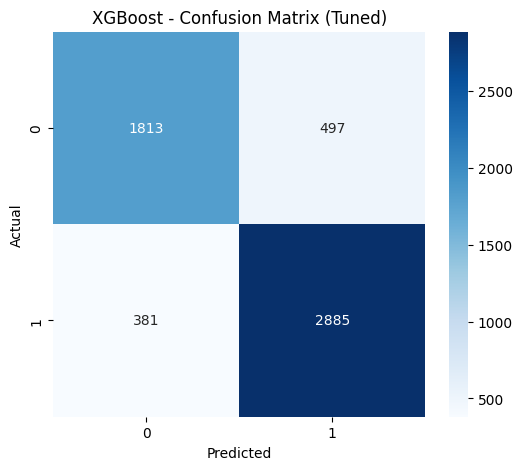

<Figure size 1000x800 with 0 Axes>

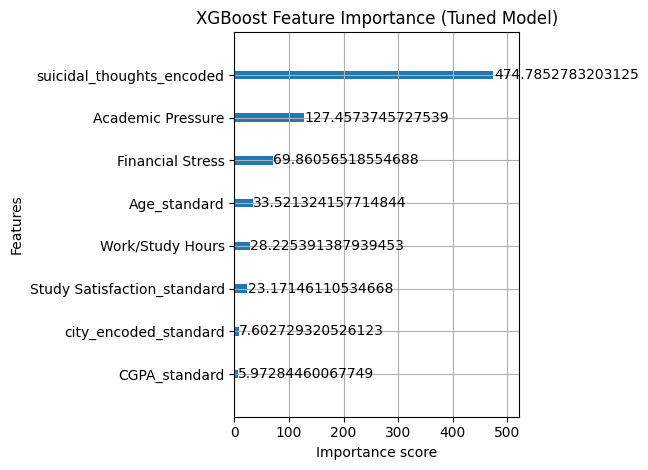


✅ Best XGBoost model saved successfully in 'models/' folder!


In [ ]:
# ====================== 1 : XGBoost Classifier ======================
print("=== 1 : XGBoost Classifier ===")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb

# ====================== 1. Algorithm Selection Rationale ======================
print("Algorithm Selected: XGBoost (Extreme Gradient Boosting)")
print("""
Rationale:
- Ensemble tree-based method → Excellent for tabular data
- Handles missing values and non-linear relationships well
- Built-in regularization (prevents overfitting)
- Fast training and high performance on classification tasks
- Provides feature importance natively
""")

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results/eda_visualizations/xgboost', exist_ok=True)

# Load dataset
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['Depression'].value_counts(normalize=True))

X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# ====================== Default XGBoost ======================
print("\nTraining Default XGBoost...")
start_time = time.time()

xgb_default = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_default.fit(X_train, y_train)

train_time_default = time.time() - start_time

y_pred = xgb_default.predict(X_test)
y_pred_proba = xgb_default.predict_proba(X_test)[:, 1]

print("=== Default XGBoost Results ===")
print(f"Training Time: {train_time_default:.2f} seconds")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------- Visualization: Confusion Matrix (Default) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/xgboost/xgboost_confusion_matrix_default.png')
plt.show()
plt.close()

# ====================== Cross-Validation ======================
print("\nPerforming 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

cv_results = cross_validate(
    xgb_default, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True
)

print("Cross-Validation Results (Mean ± Std):")
for metric in scoring:
    print(f"{metric.capitalize():12}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")

# ====================== Hyperparameter Tuning ======================
print("\nPerforming Grid Search (Hyperparameter Tuning)...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# ====================== Final Evaluation on Test Set ======================
print("\n=== Tuned XGBoost Results ===")

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# ------------------- Visualization: Confusion Matrix (Tuned) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/xgboost/xgboost_confusion_matrix_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Importance -------------------
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title('XGBoost Feature Importance (Tuned Model)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/xgboost/xgboost_feature_importance.png')
plt.show()
plt.close()

# Save the Best Model
joblib.dump(best_model, 'models/xgboost_best_model.pkl')
print("\n✅ Best XGBoost model saved successfully in 'models/' folder!")

# **Random Forest Classifier**

=== 2 : Random Forest Classifier ===
Algorithm Selected: Random Forest Classifier

Rationale:
- Ensemble of decision trees → Robust and stable performance
- Handles non-linear relationships and feature interactions well
- Built-in feature importance ranking
- Less prone to overfitting compared to single Decision Tree
- Good baseline for tabular classification tasks like student depression prediction

Dataset Shape: (27880, 13)
Target Distribution:
 Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Training set: (22304, 12)
Test set: (5576, 12)

Training Default Random Forest...
=== Default Random Forest Results ===
Training Time: 2.56 seconds
Accuracy : 0.8382
AUC Score: 0.9054
F1 Score : 0.8636

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2310
           1       0.85      0.87      0.86      3266

    accuracy                           0.84      5576
   macro avg       0.83      0.

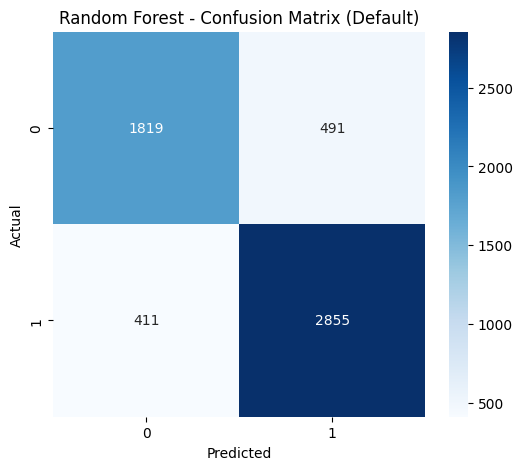

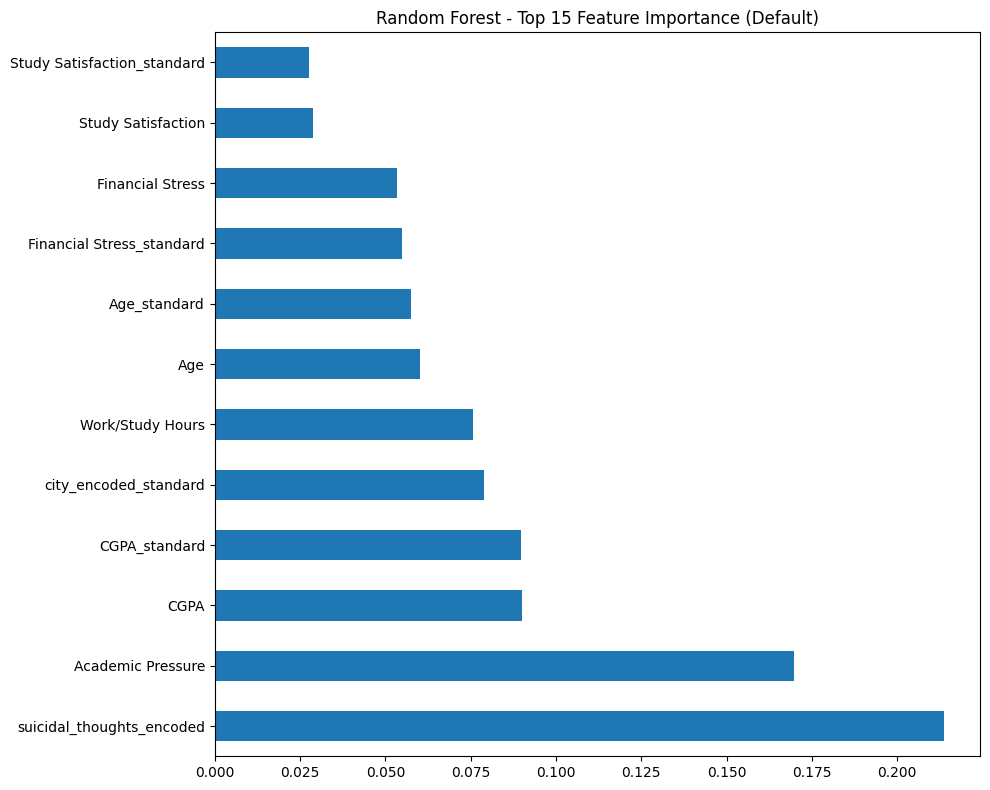


Performing 5-Fold Stratified Cross-Validation...
Cross-Validation Results (Mean ± Std):
Accuracy    : 0.8288 ± 0.0038
F1          : 0.8552 ± 0.0032
Roc_auc     : 0.9001 ± 0.0040
Precision   : 0.8473 ± 0.0043
Recall      : 0.8633 ± 0.0046

Performing Grid Search (Hyperparameter Tuning)...
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

=== Tuned Random Forest Results ===
Accuracy : 0.8407
AUC Score: 0.9131
F1 Score : 0.8666

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2310
           1       0.85      0.88      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.83      5576
weighted avg       0.84      0.84      0.84      5576



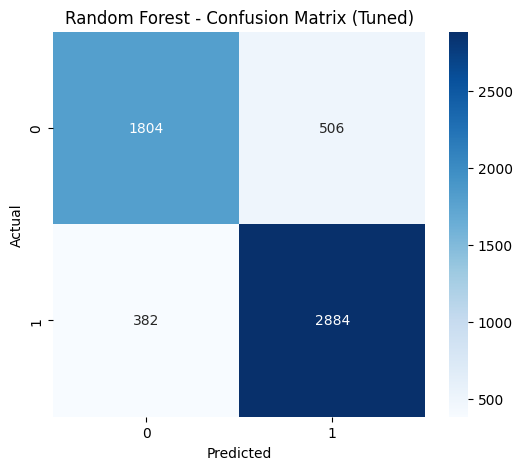

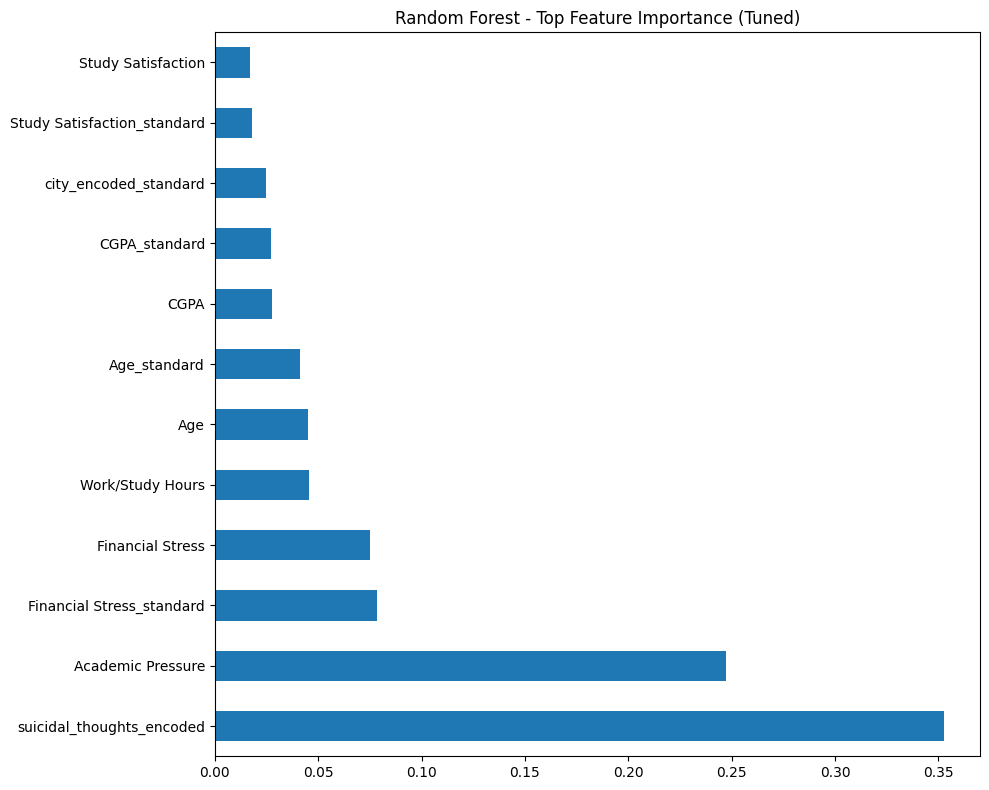


✅ Best Random Forest model saved successfully!


In [ ]:
# ====================== 2 : Random Forest Classifier ======================
print("=== 2 : Random Forest Classifier ===")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# ====================== 1. Algorithm Selection Rationale ======================
print("Algorithm Selected: Random Forest Classifier")
print("""
Rationale:
- Ensemble of decision trees → Robust and stable performance
- Handles non-linear relationships and feature interactions well
- Built-in feature importance ranking
- Less prone to overfitting compared to single Decision Tree
- Good baseline for tabular classification tasks like student depression prediction
""")

# Create required folders
os.makedirs('models', exist_ok=True)
os.makedirs('results/eda_visualizations/random_forest', exist_ok=True)

# Load final preprocessed dataset
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['Depression'].value_counts(normalize=True))

X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# ====================== Default Random Forest ======================
print("\nTraining Default Random Forest...")
start_time = time.time()

rf_default = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)
rf_default.fit(X_train, y_train)

train_time_default = time.time() - start_time

y_pred = rf_default.predict(X_test)
y_pred_proba = rf_default.predict_proba(X_test)[:, 1]

print("=== Default Random Forest Results ===")
print(f"Training Time: {train_time_default:.2f} seconds")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------- Visualization: Confusion Matrix (Default) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/random_forest/rf_confusion_matrix_default.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Importance (Default) -------------------
plt.figure(figsize=(10, 8))
importances = pd.Series(rf_default.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Random Forest - Top 15 Feature Importance (Default)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/random_forest/rf_feature_importance_default.png')
plt.show()
plt.close()

# ====================== Cross-Validation ======================
print("\nPerforming 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

cv_results = cross_validate(
    rf_default, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=2, return_train_score=True
)

print("Cross-Validation Results (Mean ± Std):")
for metric in scoring:
    print(f"{metric.capitalize():12}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")

# ====================== Hyperparameter Tuning (Optimized) ======================
print("\nPerforming Grid Search (Hyperparameter Tuning)...")

# Smaller, more efficient grid to prevent memory issues
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 10, 12, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=2),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=4,
    verbose=1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# ====================== Final Evaluation on Test Set ======================
print("\n=== Tuned Random Forest Results ===")

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# ------------------- Visualization: Confusion Matrix (Tuned) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/random_forest/rf_confusion_matrix_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Importance (Tuned) -------------------
plt.figure(figsize=(10, 8))
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Random Forest - Top Feature Importance (Tuned)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/random_forest/rf_feature_importance_tuned.png')
plt.show()
plt.close()

# Save the Best Model
joblib.dump(best_model, 'models/randomforest_best_model.pkl')
print("\n✅ Best Random Forest model saved successfully!")

# **Decision Tree Classifier**

=== 3 : Decision Tree Classifier ===
Algorithm Selected: Decision Tree Classifier

Rationale:
- Simple, interpretable white-box model
- Easy to understand and visualize decision rules
- Good for capturing non-linear patterns
- Serves as a baseline before moving to ensemble methods (Random Forest, XGBoost)
- Useful for feature importance and understanding data splits

Dataset Shape: (27880, 13)
Target Distribution:
 Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Training set: (22304, 12)
Test set: (5576, 12)

Training Default Decision Tree...
=== Default Decision Tree Results ===
Training Time: 0.15 seconds
Accuracy : 0.7663
AUC Score: 0.7612
F1 Score : 0.7985

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      2310
           1       0.81      0.79      0.80      3266

    accuracy                           0.77      5576
   macro avg       0.76      0.76      0.76      5576
weighted av

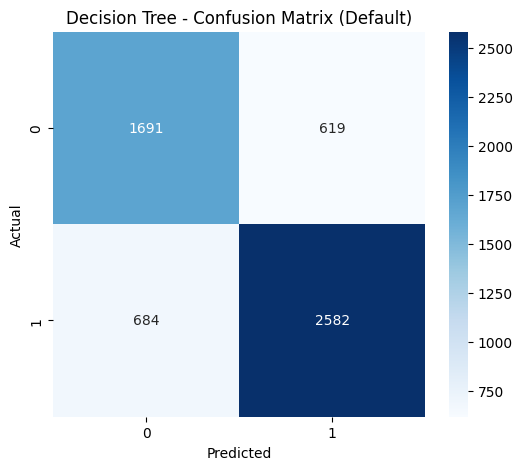

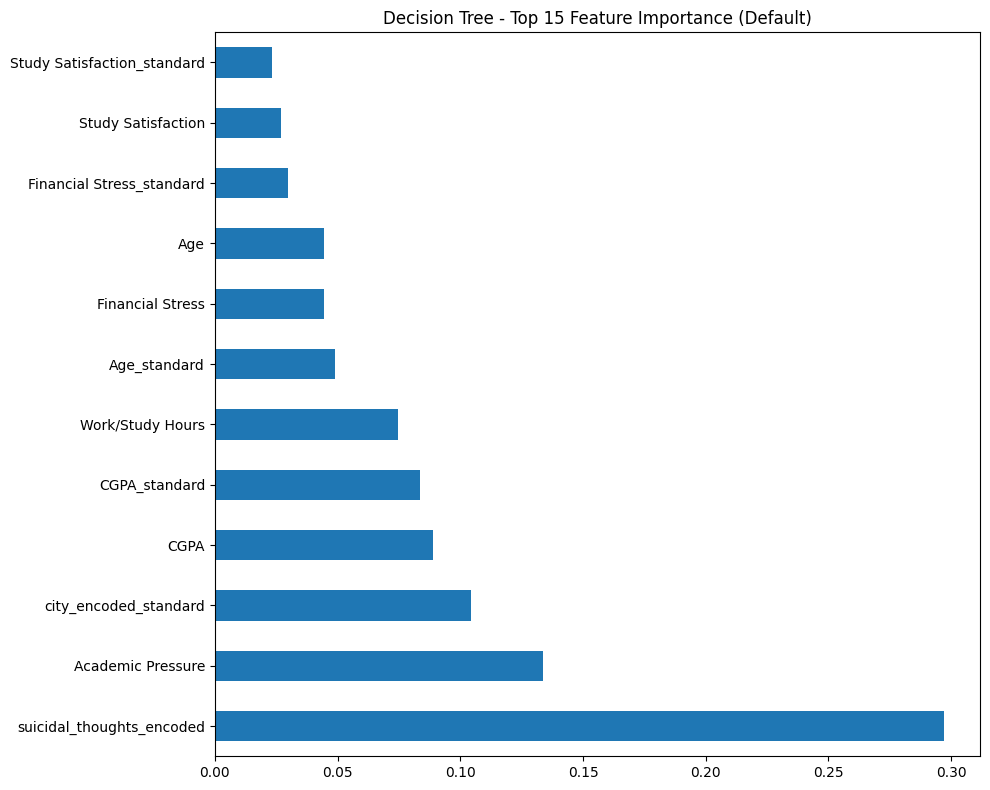


Performing 5-Fold Stratified Cross-Validation...
Cross-Validation Results (Mean ± Std):
Accuracy    : 0.7604 ± 0.0053
F1          : 0.7956 ± 0.0051
Roc_auc     : 0.7531 ± 0.0050
Precision   : 0.7953 ± 0.0035
Recall      : 0.7959 ± 0.0074

Performing Grid Search (Hyperparameter Tuning)...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== Tuned Decision Tree Results ===
Accuracy : 0.8303
AUC Score: 0.8972
F1 Score : 0.8576

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      2310
           1       0.84      0.87      0.86      3266

    accuracy                           0.83      5576
   macro avg       0.83      0.82      0.82      5576
weighted avg       0.83      0.83      0.83      5576



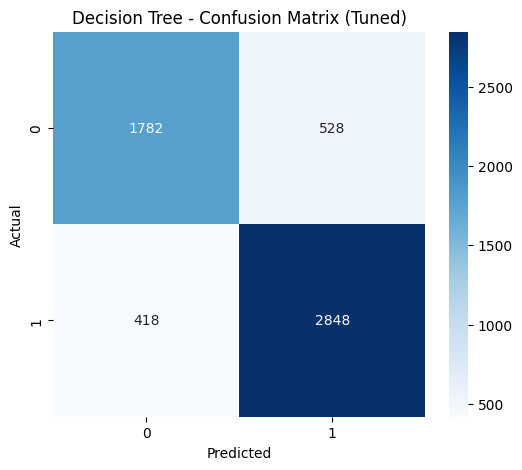

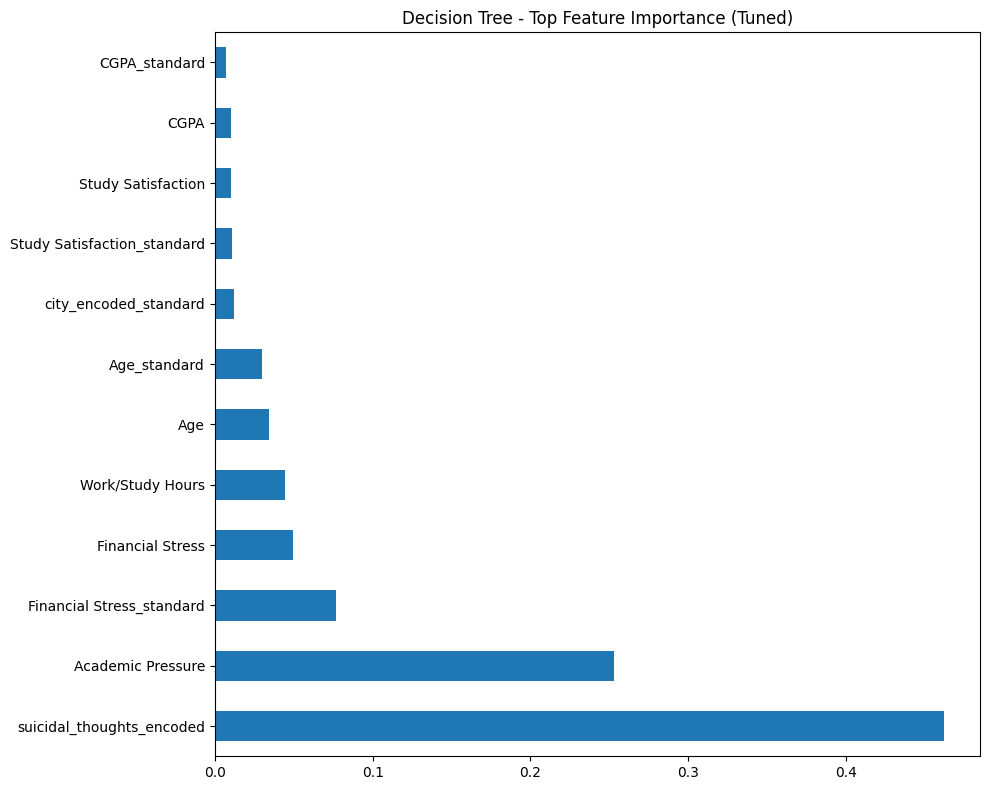


Generating Decision Tree Visualization (limited depth for readability)...


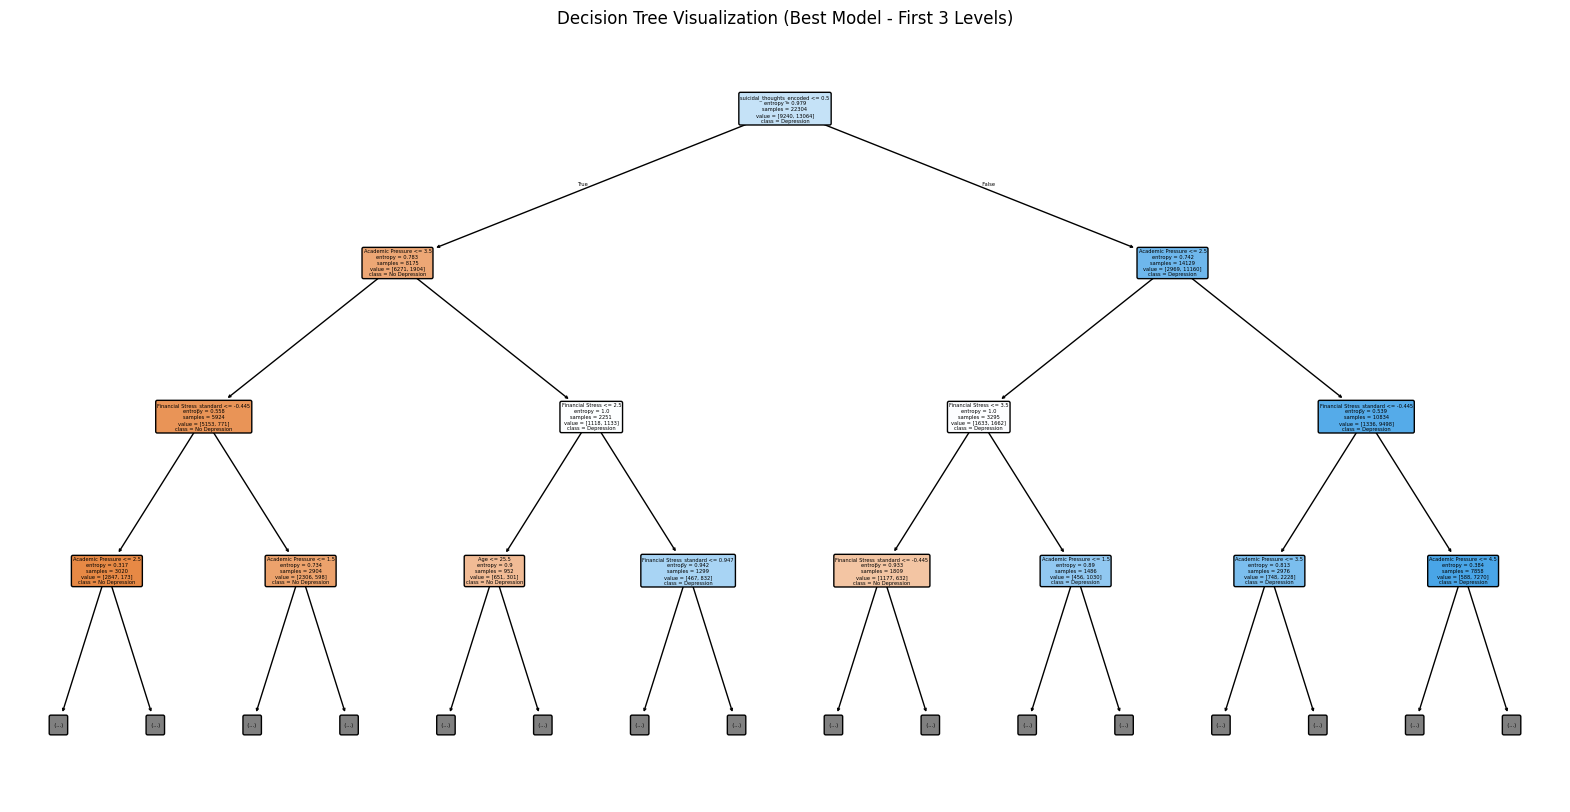


✅ Best Decision Tree model saved successfully!


In [ ]:
# ====================== 3 : Decision Tree Classifier ======================
print("=== 3 : Decision Tree Classifier ===")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ====================== 1. Algorithm Selection Rationale ======================
print("Algorithm Selected: Decision Tree Classifier")
print("""
Rationale:
- Simple, interpretable white-box model
- Easy to understand and visualize decision rules
- Good for capturing non-linear patterns
- Serves as a baseline before moving to ensemble methods (Random Forest, XGBoost)
- Useful for feature importance and understanding data splits
""")

# Create required folders
os.makedirs('models', exist_ok=True)
os.makedirs('results/eda_visualizations/decision_tree', exist_ok=True)

# Load final preprocessed dataset
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['Depression'].value_counts(normalize=True))

X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# ====================== Default Decision Tree ======================
print("\nTraining Default Decision Tree...")
start_time = time.time()

dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

train_time_default = time.time() - start_time

y_pred = dt_default.predict(X_test)
y_pred_proba = dt_default.predict_proba(X_test)[:, 1]

print("=== Default Decision Tree Results ===")
print(f"Training Time: {train_time_default:.2f} seconds")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------- Visualization: Confusion Matrix (Default) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/decision_tree/dt_confusion_matrix_default.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Importance (Default) -------------------
plt.figure(figsize=(10, 8))
importances = pd.Series(dt_default.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Decision Tree - Top 15 Feature Importance (Default)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/decision_tree/dt_feature_importance_default.png')
plt.show()
plt.close()

# ====================== Cross-Validation (Robust Performance Estimate) ======================
print("\nPerforming 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

cv_results = cross_validate(
    dt_default, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True
)

print("Cross-Validation Results (Mean ± Std):")
for metric in scoring:
    print(f"{metric.capitalize():12}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")

# ====================== Hyperparameter Tuning ======================
print("\nPerforming Grid Search (Hyperparameter Tuning)...")

param_grid = {
    'max_depth': [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# ====================== Final Evaluation on Test Set ======================
print("\n=== Tuned Decision Tree Results ===")

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# ------------------- Visualization: Confusion Matrix (Tuned) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/decision_tree/dt_confusion_matrix_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Importance (Tuned) -------------------
plt.figure(figsize=(10, 8))
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Decision Tree - Top Feature Importance (Tuned)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/decision_tree/dt_feature_importance_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Decision Tree Structure -------------------
print("\nGenerating Decision Tree Visualization (limited depth for readability)...")
plt.figure(figsize=(20, 10))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['No Depression', 'Depression'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title('Decision Tree Visualization (Best Model - First 3 Levels)')
plt.savefig('results/eda_visualizations/decision_tree/dt_visualization.png')
plt.show()
plt.close()

# Save the Best Model
joblib.dump(best_model, 'models/decision_tree_best_model.pkl')
print("\n✅ Best Decision Tree model saved successfully!")

# **Logistic Regression**

=== 4 : Logistic Regression Classifier ===
Algorithm Selected: Logistic Regression

Rationale:
- Simple and highly interpretable linear model
- Excellent baseline for binary classification
- Provides clear feature coefficients (direction and magnitude of impact)
- Computationally efficient and fast to train
- Works well when relationships are approximately linear or after good feature engineering

Dataset Shape: (27880, 13)
Target Distribution:
 Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Training set: (22304, 12)
Test set: (5576, 12)

Training Default Logistic Regression...
=== Default Logistic Regression Results ===
Training Time: 0.06 seconds
Accuracy : 0.8424
AUC Score: 0.9150
F1 Score : 0.8683

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2310
           1       0.85      0.89      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.8

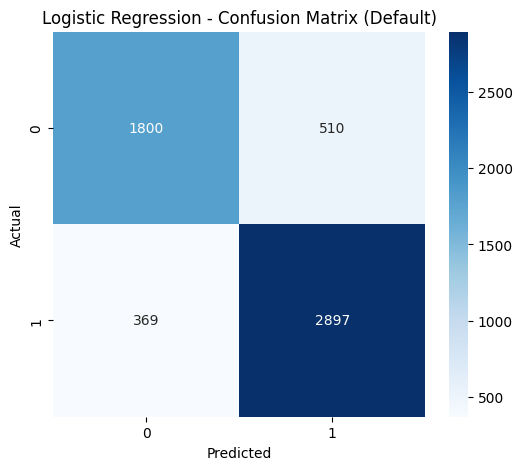

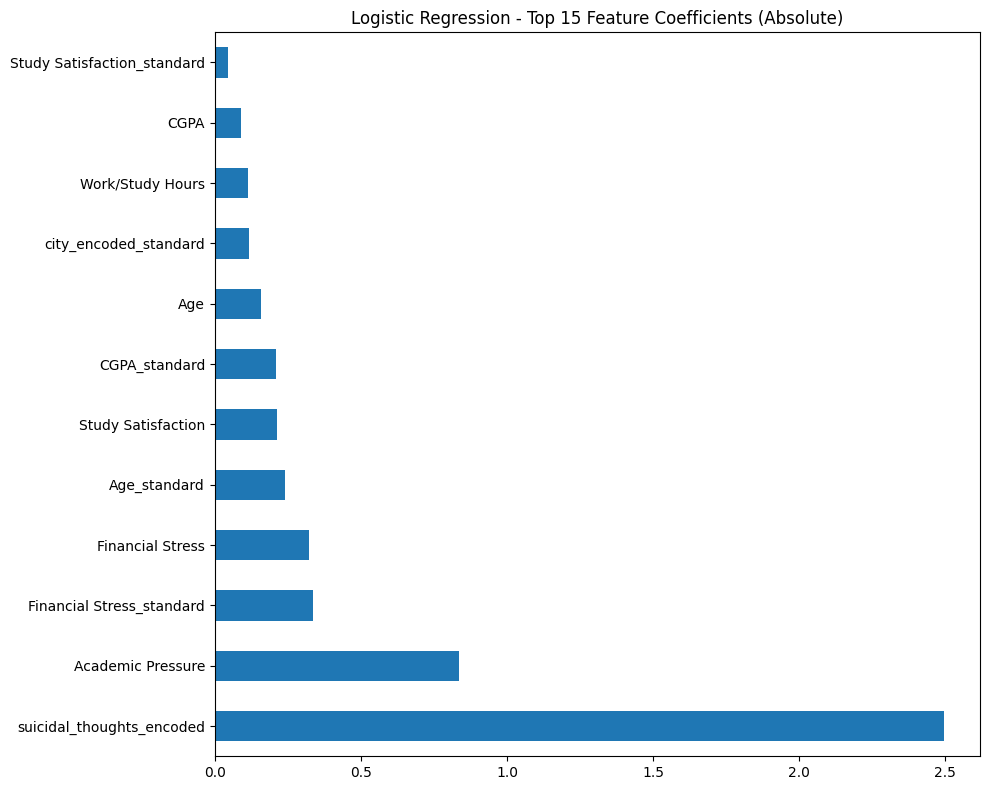


Performing 5-Fold Stratified Cross-Validation...
Cross-Validation Results (Mean ± Std):
Accuracy    : 0.8439 ± 0.0025
F1          : 0.8692 ± 0.0021
Roc_auc     : 0.9151 ± 0.0042
Precision   : 0.8535 ± 0.0026
Recall      : 0.8855 ± 0.0029

Performing Grid Search (Hyperparameter Tuning)...
Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}

=== Tuned Logistic Regression Results ===
Accuracy : 0.8424
AUC Score: 0.9150
F1 Score : 0.8683

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2310
           1       0.85      0.89      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.84      5576
weighted avg       0.84      0.84      0.84      5576



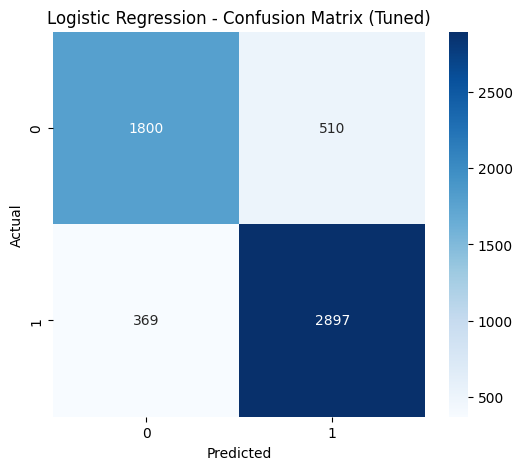

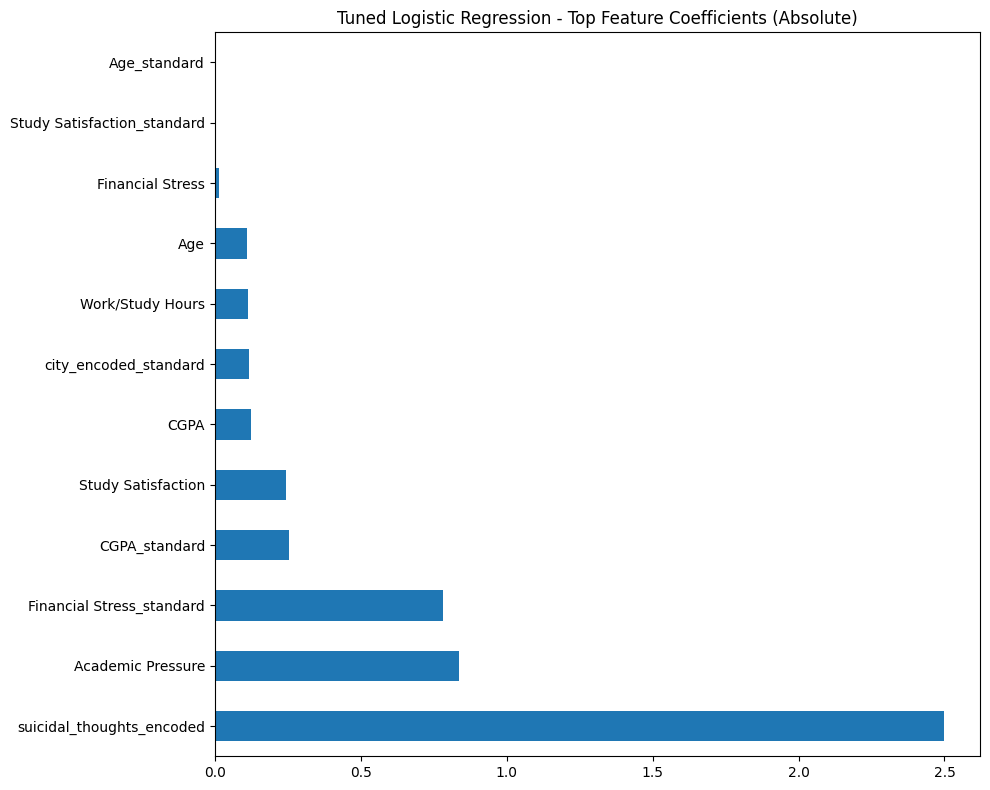


✅ Best Logistic Regression model saved successfully!


In [ ]:
# ====================== 4 : Logistic Regression ======================
print("=== 4 : Logistic Regression Classifier ===")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression

# ====================== 1. Algorithm Selection Rationale ======================
print("Algorithm Selected: Logistic Regression")
print("""
Rationale:
- Simple and highly interpretable linear model
- Excellent baseline for binary classification
- Provides clear feature coefficients (direction and magnitude of impact)
- Computationally efficient and fast to train
- Works well when relationships are approximately linear or after good feature engineering
""")

# Create required folders
os.makedirs('models', exist_ok=True)
os.makedirs('results/eda_visualizations/logistic_regression', exist_ok=True)

# Load final preprocessed dataset
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['Depression'].value_counts(normalize=True))

X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# ====================== Default Logistic Regression ======================
print("\nTraining Default Logistic Regression...")
start_time = time.time()

log_default = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='liblinear'
)
log_default.fit(X_train, y_train)

train_time_default = time.time() - start_time

y_pred = log_default.predict(X_test)
y_pred_proba = log_default.predict_proba(X_test)[:, 1]

print("=== Default Logistic Regression Results ===")
print(f"Training Time: {train_time_default:.2f} seconds")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------- Visualization: Confusion Matrix (Default) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/logistic_regression/lr_confusion_matrix_default.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Coefficients (Default) -------------------
plt.figure(figsize=(10, 8))
coefficients = pd.Series(log_default.coef_[0], index=X.columns)
coefficients = coefficients.abs().sort_values(ascending=False)
coefficients.head(15).plot(kind='barh')
plt.title('Logistic Regression - Top 15 Feature Coefficients (Absolute)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/logistic_regression/lr_feature_coefficients_default.png')
plt.show()
plt.close()

# ====================== Cross-Validation ======================
print("\nPerforming 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

cv_results = cross_validate(
    log_default, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=2, return_train_score=True
)

print("Cross-Validation Results (Mean ± Std):")
for metric in scoring:
    print(f"{metric.capitalize():12}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")

# ====================== Hyperparameter Tuning (Fixed) ======================
print("\nPerforming Grid Search (Hyperparameter Tuning)...")

# Fixed param_grid using list of dicts to avoid incompatible combinations
param_grid = [
    # L1 Penalty
    {'penalty': ['l1'],
     'solver': ['liblinear', 'saga'],
     'C': [0.01, 0.1, 1, 10, 100],
     'max_iter': [1000, 2000]},

    # L2 Penalty
    {'penalty': ['l2'],
     'solver': ['liblinear', 'saga'],
     'C': [0.01, 0.1, 1, 10, 100],
     'max_iter': [1000, 2000]},

    # ElasticNet Penalty (only with saga solver)
    {'penalty': ['elasticnet'],
     'solver': ['saga'],
     'C': [0.01, 0.1, 1, 10, 100],
     'l1_ratio': [0.1, 0.5, 0.9],
     'max_iter': [1000, 2000]}
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=4,
    verbose=1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# ====================== Final Evaluation on Test Set ======================
print("\n=== Tuned Logistic Regression Results ===")

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# ------------------- Visualization: Confusion Matrix (Tuned) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/logistic_regression/lr_confusion_matrix_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Coefficients (Tuned) -------------------
plt.figure(figsize=(10, 8))
coefficients_best = pd.Series(best_model.coef_[0], index=X.columns)
coefficients_best = coefficients_best.abs().sort_values(ascending=False)
coefficients_best.head(15).plot(kind='barh')
plt.title('Tuned Logistic Regression - Top Feature Coefficients (Absolute)')
plt.tight_layout()
plt.savefig('results/eda_visualizations/logistic_regression/lr_feature_coefficients_tuned.png')
plt.show()
plt.close()

# Save the Best Model
joblib.dump(best_model, 'models/logistic_regression_best_model.pkl')
print("\n✅ Best Logistic Regression model saved successfully!")

# **SVM Classifier**

=== 5 : Support Vector Machine (SVM) Classifier ===
Algorithm Selected: Support Vector Machine (SVM)

Rationale:
- Powerful for high-dimensional data and complex decision boundaries
- Effective with different kernels (linear, RBF, etc.)
- Robust to outliers with proper regularization (C parameter)
- Good for binary classification tasks

Dataset Shape: (27880, 13)
Target Distribution:
 Depression
1    0.585725
0    0.414275
Name: proportion, dtype: float64
Training set: (22304, 12)
Test set: (5576, 12)

Training Default SVM (Linear Kernel)...
=== Default SVM Results ===
Training Time: 140.94 seconds
Accuracy : 0.8425
AUC Score: 0.9151
F1 Score : 0.8686

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2310
           1       0.85      0.89      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.84      5576
weighted avg       0.84      0.84      0.84 

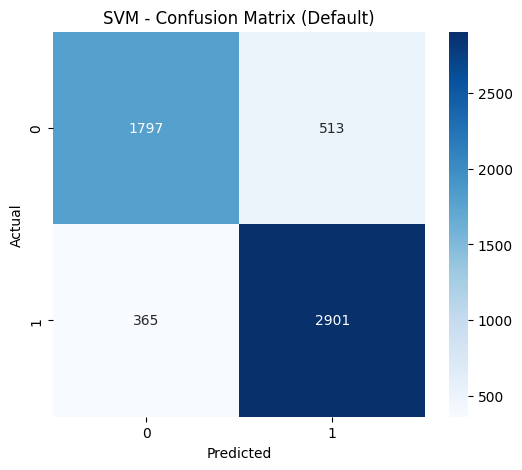

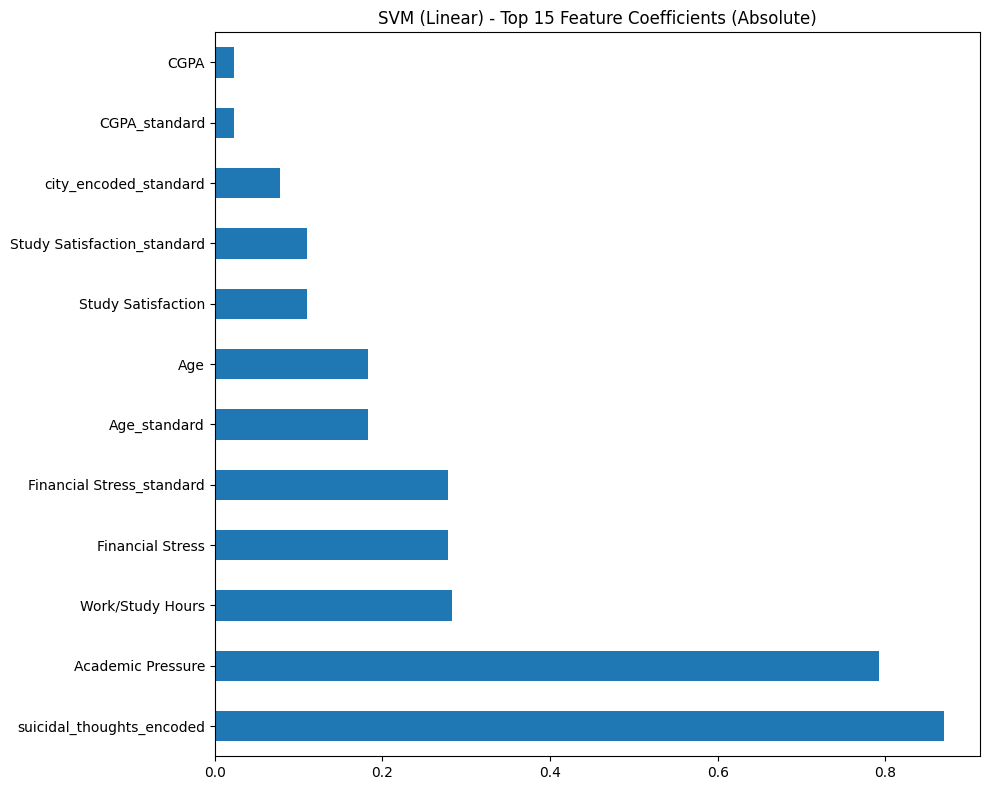


Performing 5-Fold Stratified Cross-Validation...
Cross-Validation Results (Mean ± Std):
Accuracy    : 0.8432 ± 0.0021
F1          : 0.8689 ± 0.0016
Roc_auc     : 0.9150 ± 0.0042
Precision   : 0.8514 ± 0.0028
Recall      : 0.8872 ± 0.0019

Performing Grid Search (Hyperparameter Tuning)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'svm__C': 0.1}

=== Tuned SVM Results ===
Accuracy : 0.8422
AUC Score: 0.9151
F1 Score : 0.8682

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2310
           1       0.85      0.89      0.87      3266

    accuracy                           0.84      5576
   macro avg       0.84      0.83      0.84      5576
weighted avg       0.84      0.84      0.84      5576



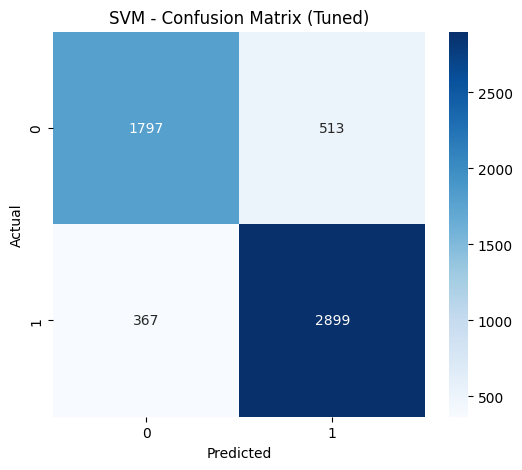

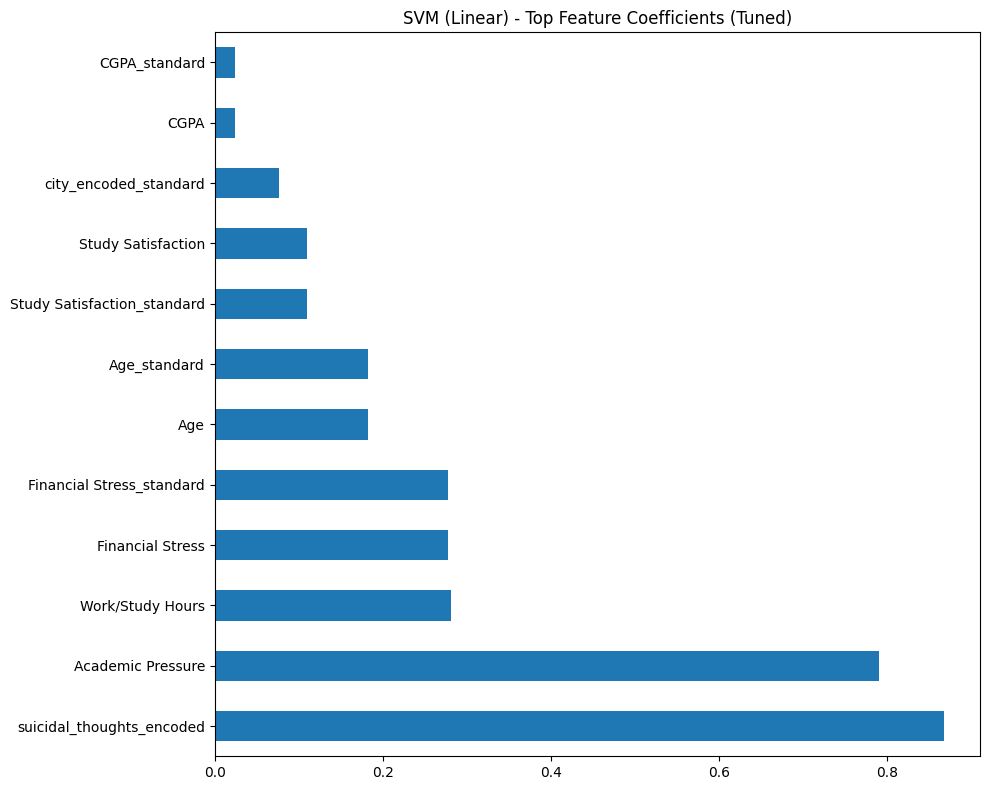


✅ Best SVM model saved successfully!


In [ ]:
# ====================== 5 : SVM Classifier ======================
print("=== 5 : Support Vector Machine (SVM) Classifier ===")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ====================== 1. Algorithm Selection Rationale ======================
print("Algorithm Selected: Support Vector Machine (SVM)")
print("""
Rationale:
- Powerful for high-dimensional data and complex decision boundaries
- Effective with different kernels (linear, RBF, etc.)
- Robust to outliers with proper regularization (C parameter)
- Good for binary classification tasks
""")

# Create required folders
os.makedirs('models', exist_ok=True)
os.makedirs('results/eda_visualizations/svm', exist_ok=True)

# Load final preprocessed dataset
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
print("Dataset Shape:", df.shape)
print("Target Distribution:\n", df['Depression'].value_counts(normalize=True))

X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# ====================== Default SVM with Scaling ======================
print("\nTraining Default SVM (Linear Kernel)...")
start_time = time.time()

svm_default = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='linear',
        probability=True,
        random_state=42,
        max_iter=-1,
        tol=1e-4,
        C=1.0
    ))
])

svm_default.fit(X_train, y_train)
train_time_default = time.time() - start_time

y_pred = svm_default.predict(X_test)
y_pred_proba = svm_default.predict_proba(X_test)[:, 1]

print("=== Default SVM Results ===")
print(f"Training Time: {train_time_default:.2f} seconds")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------- Visualization: Confusion Matrix (Default) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SVM - Confusion Matrix (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/svm/svm_confusion_matrix_default.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Coefficients (Default) -------------------
svm_model = svm_default.named_steps['svm']
if hasattr(svm_model, 'coef_'):
    plt.figure(figsize=(10, 8))
    coefficients = pd.Series(svm_model.coef_[0], index=X.columns)
    coefficients = coefficients.abs().sort_values(ascending=False)
    coefficients.head(15).plot(kind='barh')
    plt.title('SVM (Linear) - Top 15 Feature Coefficients (Absolute)')
    plt.tight_layout()
    plt.savefig('results/eda_visualizations/svm/svm_feature_coefficients_default.png')
    plt.show()
    plt.close()

# ====================== Cross-Validation ======================
print("\nPerforming 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

cv_results = cross_validate(
    svm_default, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=2, return_train_score=True
)

print("Cross-Validation Results (Mean ± Std):")
for metric in scoring:
    print(f"{metric.capitalize():12}: {cv_results[f'test_{metric}'].mean():.4f} ± {cv_results[f'test_{metric}'].std():.4f}")

# ====================== Hyperparameter Tuning ======================
print("\nPerforming Grid Search (Hyperparameter Tuning)...")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='linear',
        probability=True,
        random_state=42,
        max_iter=-1
    ))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=4,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# ====================== Final Evaluation on Test Set ======================
print("\n=== Tuned SVM Results ===")

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# ------------------- Visualization: Confusion Matrix (Tuned) -------------------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('SVM - Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/eda_visualizations/svm/svm_confusion_matrix_tuned.png')
plt.show()
plt.close()

# ------------------- Visualization: Feature Coefficients (Tuned) -------------------
svm_model_best = best_model.named_steps['svm']
if hasattr(svm_model_best, 'coef_'):
    plt.figure(figsize=(10, 8))
    coefficients_best = pd.Series(svm_model_best.coef_[0], index=X.columns)
    coefficients_best = coefficients_best.abs().sort_values(ascending=False)
    coefficients_best.head(15).plot(kind='barh')
    plt.title('SVM (Linear) - Top Feature Coefficients (Tuned)')
    plt.tight_layout()
    plt.savefig('results/eda_visualizations/svm/svm_feature_coefficients_tuned.png')
    plt.show()
    plt.close()

# Save the Best Model
joblib.dump(best_model, 'models/svm_best_model.pkl')
print("\n✅ Best SVM model saved successfully!")

# **FINAL MODEL COMPARISON**


FINAL MODEL COMPARISON - ALL TUNED MODELS
✅ Loaded XGBoost
✅ Loaded Random Forest
✅ Loaded Decision Tree
✅ Loaded Logistic Regression
✅ Loaded SVM

Evaluating all models on Test Set...

🏆 MODEL COMPARISON TABLE (Sorted by F1-Score):
                 Model  Accuracy     AUC  F1-Score  Prediction Time (s)
3  Logistic Regression    0.8424  0.9150    0.8683               0.0072
4                  SVM    0.8422  0.9151    0.8682               4.1244
0              XGBoost    0.8425  0.9155    0.8679               0.0385
1        Random Forest    0.8407  0.9131    0.8666               0.4169
2        Decision Tree    0.8303  0.8972    0.8576               0.0081


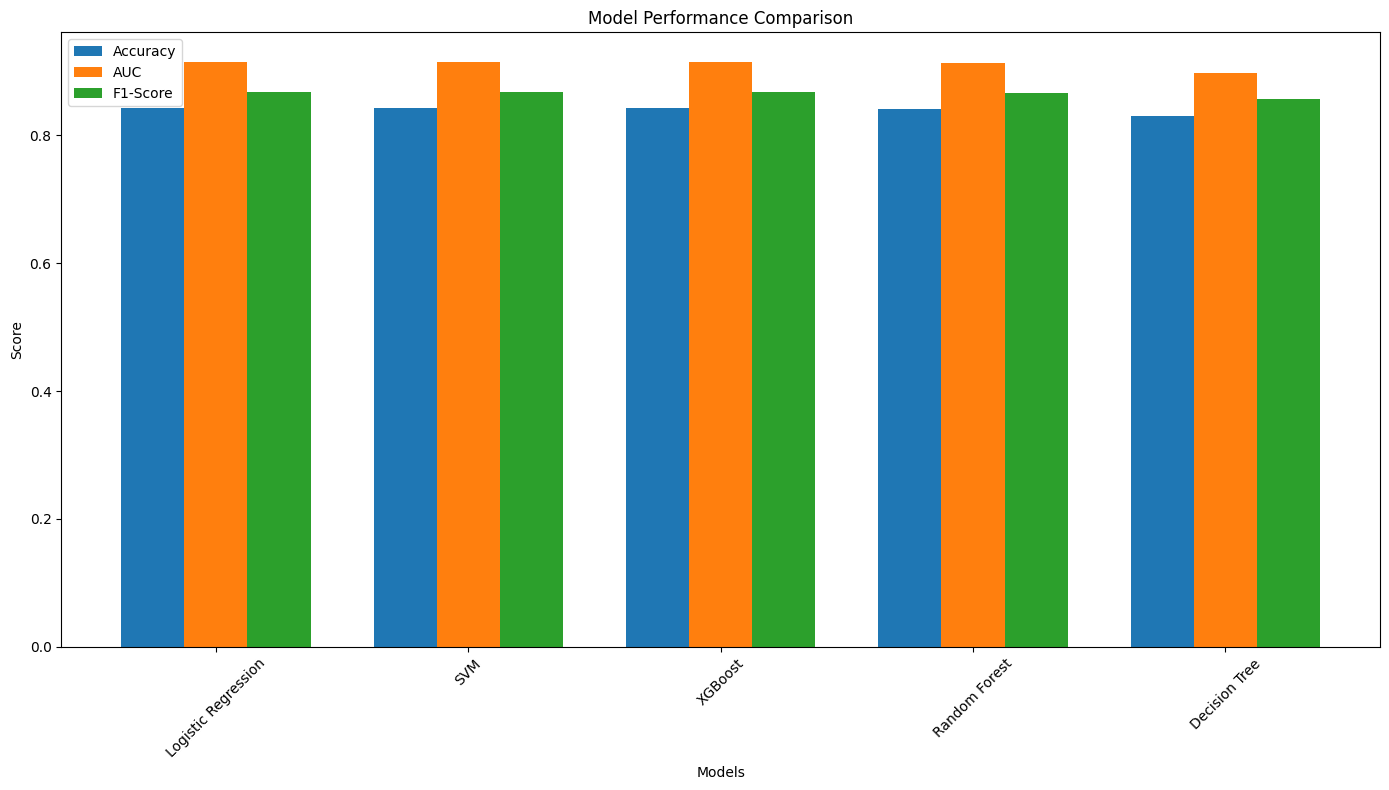

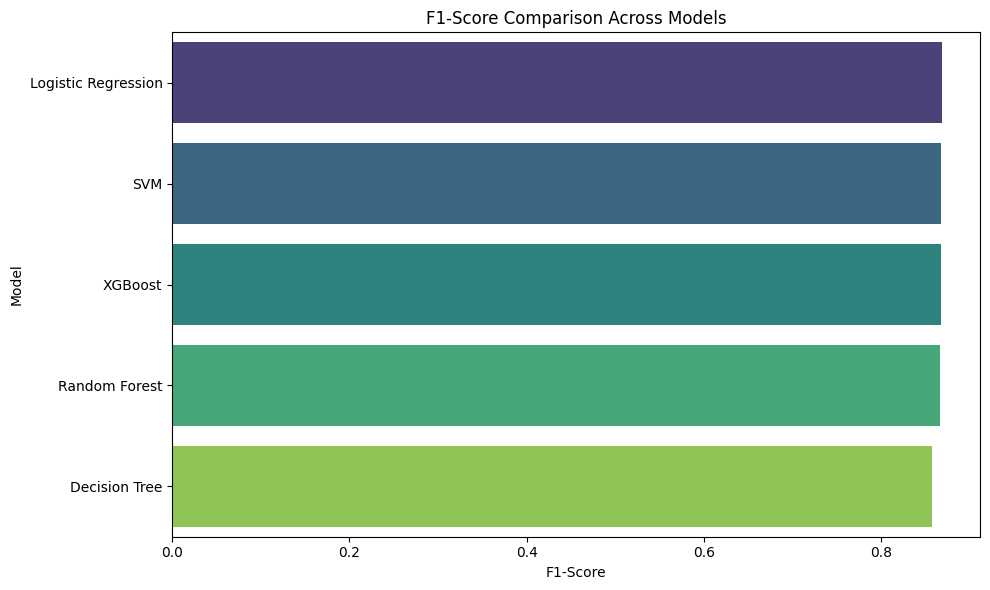


📊 Comparison table and plots saved in 'results/' folder!

🎯 BEST PERFORMING MODEL: **Logistic Regression**
   F1-Score: 0.8683
   AUC     : 0.915
   Accuracy: 0.8424

✅ Model Comparison Complete!


In [ ]:
# ====================== FINAL MODEL COMPARISON ======================
print("\n" + "="*60)
print("FINAL MODEL COMPARISON - ALL TUNED MODELS")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

# Load test data (consistent across all models)
df = pd.read_csv('final_preprocessed_student_depression_dataset.csv')
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load all best models
models = {}
model_names = {
    'XGBoost': 'models/xgboost_best_model.pkl',
    'Random Forest': 'models/randomforest_best_model.pkl',
    'Decision Tree': 'models/decision_tree_best_model.pkl',
    'Logistic Regression': 'models/logistic_regression_best_model.pkl',
    'SVM': 'models/svm_best_model.pkl'
}

for name, path in model_names.items():
    try:
        models[name] = joblib.load(path)
        print(f"✅ Loaded {name}")
    except FileNotFoundError:
        print(f"⚠️  Model not found: {path}")

# ====================== Performance Comparison on Test Set ======================
results = []

print("\nEvaluating all models on Test Set...")

for name, model in models.items():
    start_time = time.time()
    y_pred = model.predict(X_test)

    # Handle models that may not have predict_proba
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        y_pred_proba = None
        auc = None

    pred_time = time.time() - start_time

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'AUC': round(auc, 4) if auc is not None else None,
        'F1-Score': round(f1, 4),
        'Prediction Time (s)': round(pred_time, 4)
    })

# Create Comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False)

print("\n🏆 MODEL COMPARISON TABLE (Sorted by F1-Score):")
print(comparison_df.round(4))

# ====================== Visualizations ======================

# Bar Chart Comparison
plt.figure(figsize=(14, 8))

metrics = ['Accuracy', 'AUC', 'F1-Score']
x = np.arange(len(comparison_df['Model']))
width = 0.25

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, comparison_df[metric], width=width, label=metric)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width, comparison_df['Model'], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('results/eda_visualizations/model_comparison_bar.png')
plt.show()

# Horizontal Bar for F1-Score (Fixed version)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='F1-Score',
    y='Model',
    data=comparison_df,
    palette='viridis',
    hue='Model',
    legend=False
)
plt.title('F1-Score Comparison Across Models')
plt.tight_layout()
plt.savefig('results/eda_visualizations/model_comparison_f1.png')
plt.show()

# Save comparison table
comparison_df.to_csv('results/model_comparison.csv', index=False)
print("\n📊 Comparison table and plots saved in 'results/' folder!")

# ====================== Best Model Summary ======================
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🎯 BEST PERFORMING MODEL: **{best_model_name}**")
print(f"   F1-Score: {comparison_df.iloc[0]['F1-Score']}")
print(f"   AUC     : {comparison_df.iloc[0]['AUC']}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']}")

print("\n✅ Model Comparison Complete!")